# Projekt

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc


In [9]:
kolumny = [
        "id", "age", "year", "sex", "glang", "part", "job", "stud_h", "health",
        "psyt", "jspe", "qcae_cog", "qcae_aff", "amsp", "erec_mean", "cesd",
        "stai_t", "mbi_ex", "mbi_cy", "mbi_ea"
    ]

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

def load_mental_health_data():

    path = pathlib.Path("Data Carrard et al. 2022 MedTeach.csv")
    
    # Wczytanie danych z zachowaniem oryginalnych nagłówków
    df = pd.read_csv(path)
    
    # Ustawienie 'id' jako indeksu
    df.set_index("id", inplace=True)


    # Standardowy punkt odcięcia (cut-off) dla skali CES-D wynosi 16.
    # Wynik cesd >= 16 wskazuje na istotne symptomy depresyjne (ryzyko depresji).
    # Tworzymy NOWĄ kolumnę 'cesd_risk', pozostawiając oryginalne 'cesd' bez zmian.

    df['cesd_risk'] = (df['cesd'] >= 16).astype(int)

    # Instrukcja zwracająca kompletny i zmodyfikowany DataFrame
    return df

# Wybór zbioru danych i wywołanie poprawionej funkcji
df = load_mental_health_data()

### W dalszej części cesd nie będzie używane na rzecz cesd_risk

## Regresja Logistyczna

#### Standaryzacja

In [10]:
X = df[["age", "year", "sex", "glang", "part", "job", "stud_h", "health",
        "psyt", "jspe", "qcae_cog", "qcae_aff", "amsp", "erec_mean",
        "stai_t", "mbi_ex", "mbi_cy", "mbi_ea"]]
y = df['cesd_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standaryzacja
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Wyświetlenie statystyk (Poprawka: używamy .iloc dla DataFrame)
print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")

# Wypisywanie przedziałów zeskalowanych wartości
print(f"{'Cecha':<15} | {'Zakres przed skalowaniem':<25} | {'Zakres po skalowaniu'}")
print("-" * 75)

for i, col_name in enumerate(X_train.columns):
    # Dane przed skalowaniem (z DataFrame X_train)
    orig_min = X_train.iloc[:, i].min()
    orig_max = X_train.iloc[:, i].max()
    
    # Dane po skalowaniu (z tablicy numpy X_train_scaled)
    scaled_min = X_train_scaled[:, i].min()
    scaled_max = X_train_scaled[:, i].max()
    
    print(f"{col_name:<15} |      [{orig_min:>6.1f}, {orig_max:>6.1f}]     |      [{scaled_min:>6.2f}, {scaled_max:>6.2f}]")

Training set: 708 samples
Test set:     178 samples
Cecha           | Zakres przed skalowaniem  | Zakres po skalowaniu
---------------------------------------------------------------------------
age             |      [  17.0,   44.0]     |      [ -1.66,   6.67]
year            |      [   1.0,    6.0]     |      [ -1.18,   1.67]
sex             |      [   1.0,    3.0]     |      [ -1.47,   2.80]
glang           |      [   1.0,  121.0]     |      [ -0.42,   3.25]
part            |      [   0.0,    1.0]     |      [ -1.14,   0.88]
job             |      [   0.0,    1.0]     |      [ -0.73,   1.37]
stud_h          |      [   0.0,   70.0]     |      [ -1.61,   2.82]
health          |      [   1.0,    5.0]     |      [ -2.62,   1.15]
psyt            |      [   0.0,    1.0]     |      [ -0.54,   1.87]
jspe            |      [  67.0,  125.0]     |      [ -4.50,   2.13]
qcae_cog        |      [  38.0,   76.0]     |      [ -3.19,   2.69]
qcae_aff        |      [  18.0,   47.0]     |      [ -3.1

In [11]:
model = LogisticRegression(random_state=42, max_iter=5000)
model.fit(X_train_scaled, y_train)

# Tworzenie predykcji
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)

# Ewaluacja
train_acc = model.score(X_train_scaled, y_train)
test_acc = model.score(X_test_scaled, y_test)

print(f"\nTraining accuracy: {train_acc:.2%}")
print(f"Test accuracy:     {test_acc:.2%}")


Training accuracy: 83.05%
Test accuracy:     78.65%


In [12]:
def binary_cross_entropy(y_true, y_pred_prob):
    eps = 1e-15
    y_pred_prob = np.clip(y_pred_prob, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob))
    return loss

# Praktyczne zastosowanie: Obliczanie straty wytrenowanego modelu
# Zakładamy, że 'model' to regresja logistyczna wytrenowana wcześniej
y_test_probs = model.predict_proba(X_test_scaled)[:, 1]

# Obliczamy stratę dla zbioru testowego
final_loss = binary_cross_entropy(y_test, y_test_probs)

print(f"Ostateczna strata (Log Loss) na zbiorze testowym: {final_loss:.4f}")

Ostateczna strata (Log Loss) na zbiorze testowym: 0.4470


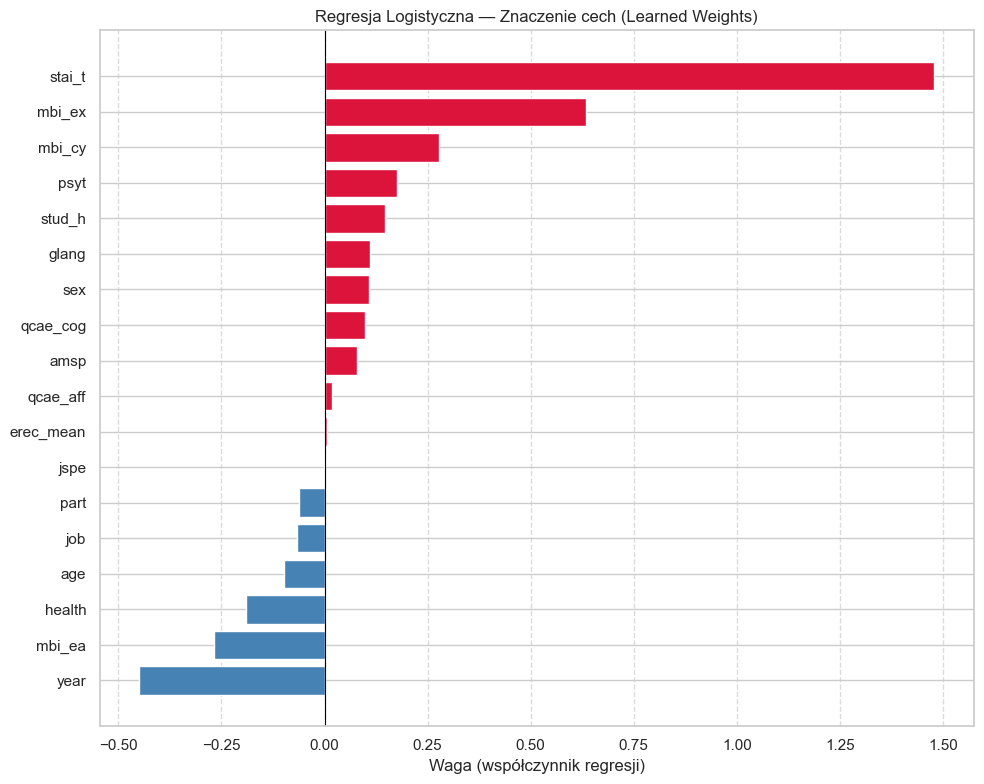


Punkt przecięcia (Intercept/Bias): 0.1642


In [13]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
}).sort_values('Weight')

plt.figure(figsize=(10, 8))

# Kolory: czerwony dla dodatnich (podnoszą ryzyko), niebieski dla ujemnych (obniżają)
colors = ['steelblue' if w < 0 else 'crimson' for w in coef_df['Weight']]

plt.barh(coef_df['Feature'], coef_df['Weight'], color=colors)
plt.xlabel('Waga (współczynnik regresji)')
plt.title('Regresja Logistyczna — Znaczenie cech (Learned Weights)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nPunkt przecięcia (Intercept/Bias): {model.intercept_[0]:.4f}")

In [14]:
print("=== Szczegółowy Raport Klasyfikacji Regresji Logistycznej ===\n")
print(classification_report(y_test, y_pred, target_names=['Depresja', 'Brak depresji']))

=== Szczegółowy Raport Klasyfikacji Regresji Logistycznej ===

               precision    recall  f1-score   support

     Depresja       0.77      0.79      0.78        84
Brak depresji       0.80      0.79      0.80        94

     accuracy                           0.79       178
    macro avg       0.79      0.79      0.79       178
 weighted avg       0.79      0.79      0.79       178



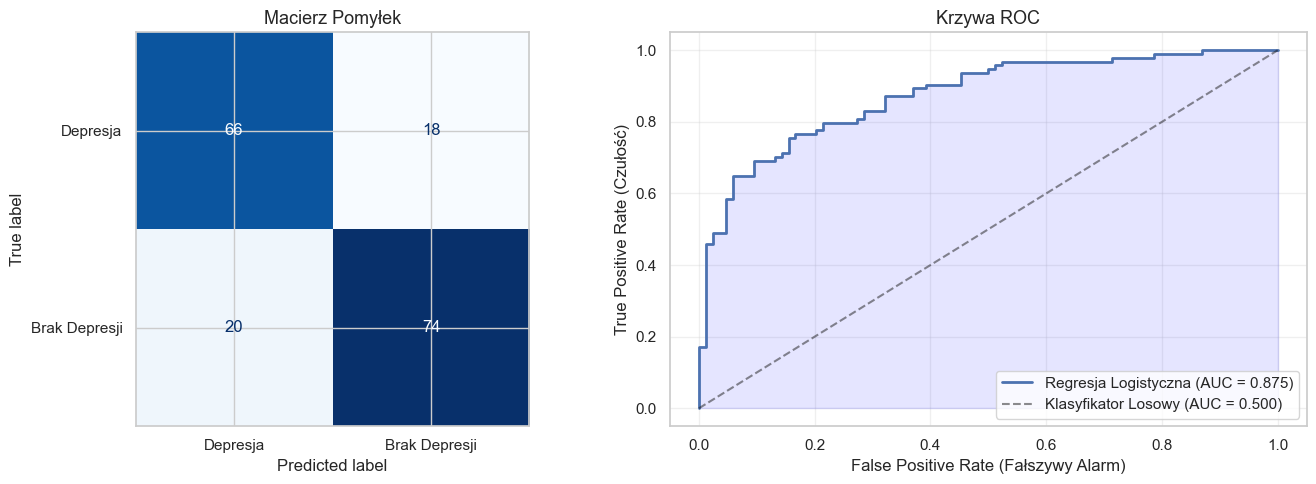


Wynik AUC = 0.875


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Confusion Matrix (Macierz Pomyłek)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Depresja', 'Brak Depresji'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Macierz Pomyłek', fontsize=13)

# Wykres 2: ROC Curve (Krzywa ROC)
# Wyliczamy prawdopodobieństwa dla klasy "Depresja" (indeks 1)
y_scores = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'Regresja Logistyczna (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nWynik AUC = {roc_auc:.3f}")

## MLP

### Dane testowe i treningowe mają taki sam rozmiar

In [16]:
print('Rozmiar zbioru treningowego:', X_train.shape)
print('Rozmiar zbioru testowego:', X_test.shape)

Rozmiar zbioru treningowego: (708, 18)
Rozmiar zbioru testowego: (178, 18)


In [17]:
categorical_features = ['year', 'sex', 'glang', 'part', 'job', 'health', 'psyt']
numeric_features = [col for col in X.columns if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Zmienne liczbowe:', numeric_features)
print('Zmienne kategoryczne:', categorical_features)

Zmienne liczbowe: ['age', 'stud_h', 'jspe', 'qcae_cog', 'qcae_aff', 'amsp', 'erec_mean', 'stai_t', 'mbi_ex', 'mbi_cy', 'mbi_ea']
Zmienne kategoryczne: ['year', 'sex', 'glang', 'part', 'job', 'health', 'psyt']


In [18]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation='relu',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20
)

# 2. Tworzenie prostego Pipeline (skalowanie/preprocessing + model)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', mlp)
])

In [19]:
pipeline.fit(X_train, y_train)

# Prognozy klas (0 lub 1) oraz prawdopodobieństw (potrzebne do AUC)
y_pred = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 1]

# Obliczanie metryk klasyfikacji binarnej
results_clf = pd.DataFrame({
    'Metryka': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC Score'],
    'Wartość': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_probs)
    ]
})

display(results_clf)
print("=== Szczegółowy Raport Klasyfikacji MLP ===\n")
print(classification_report(y_test, y_pred, target_names=['Depresja', 'Brak depresji']))

,Metryka,Wartość
0,Accuracy,0.758427
1,Precision,0.738318
2,Recall,0.840426
3,F1-Score,0.786070
4,AUC Score,0.876393


=== Szczegółowy Raport Klasyfikacji MLP ===

               precision    recall  f1-score   support

     Depresja       0.79      0.67      0.72        84
Brak depresji       0.74      0.84      0.79        94

     accuracy                           0.76       178
    macro avg       0.76      0.75      0.75       178
 weighted avg       0.76      0.76      0.76       178



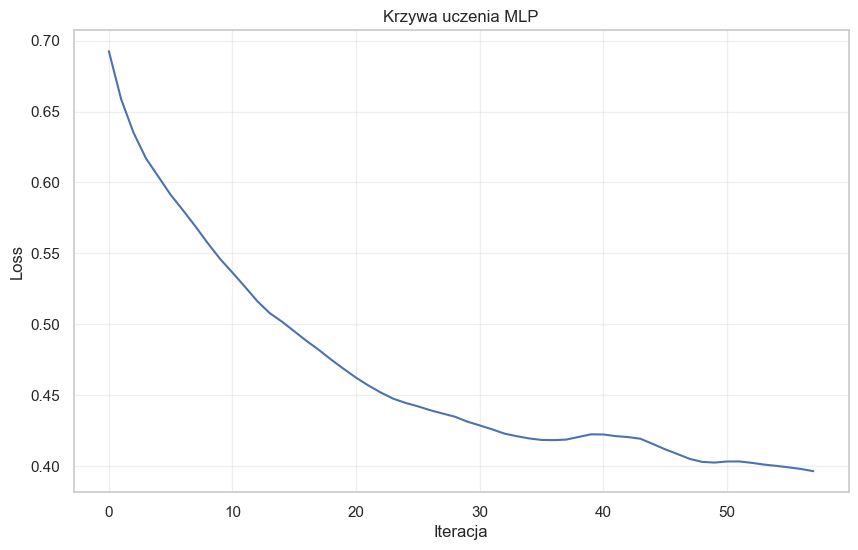

Liczba wykonanych iteracji: 58


In [20]:
mlp_model = pipeline.named_steps['model']

plt.figure()
plt.plot(mlp_model.loss_curve_)
plt.title('Krzywa uczenia MLP')
plt.xlabel('Iteracja')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()

print('Liczba wykonanych iteracji:', mlp_model.n_iter_)

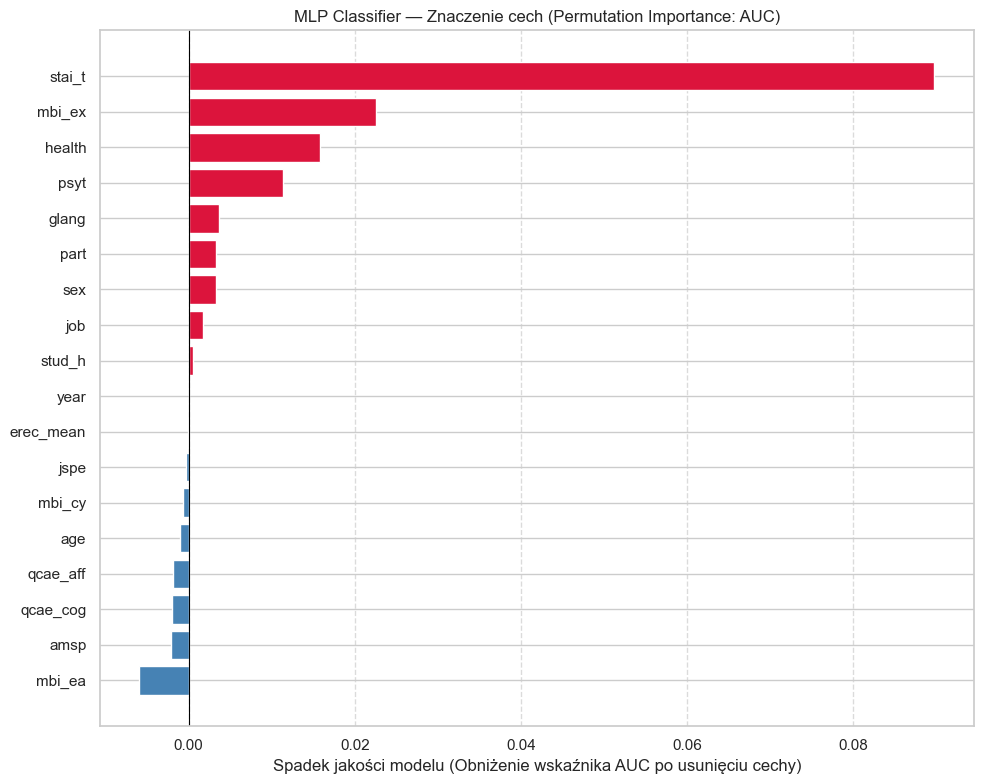


Wyjściowy wyraz wolny (Output Layer Bias): 0.1483


In [21]:
importance = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'  # Zmiana metryki na odpowiednią dla klasyfikacji!
)

# Tworzenie DataFrame (sortujemy od najmniej ważnych/szkodliwych do najważniejszych)
mlp_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': importance.importances_mean
}).sort_values('Importance')

# Rysowanie wykresu słupkowego
plt.figure(figsize=(10, 8))

# Kolory: crimson dla dodatnich (ważne cechy), steelblue dla ujemnych (szum)
colors = ['steelblue' if w < 0 else 'crimson' for w in mlp_importance_df['Importance']]

plt.barh(mlp_importance_df['Feature'], mlp_importance_df['Importance'], color=colors)
plt.xlabel('Spadek jakości modelu (Obniżenie wskaźnika AUC po usunięciu cechy)')
plt.title('MLP Classifier — Znaczenie cech (Permutation Importance: AUC)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Wyciągnięcie Biasu warstwy wyjściowej
mlp_model = pipeline.named_steps['model']
print(f"\nWyjściowy wyraz wolny (Output Layer Bias): {mlp_model.intercepts_[-1][0]:.4f}")

Model stwierdza jakie zmienne są ważne tutaj pokazuje tak jak w regresji logistycznej, że poziom lęku jest ważnym predykatorem.

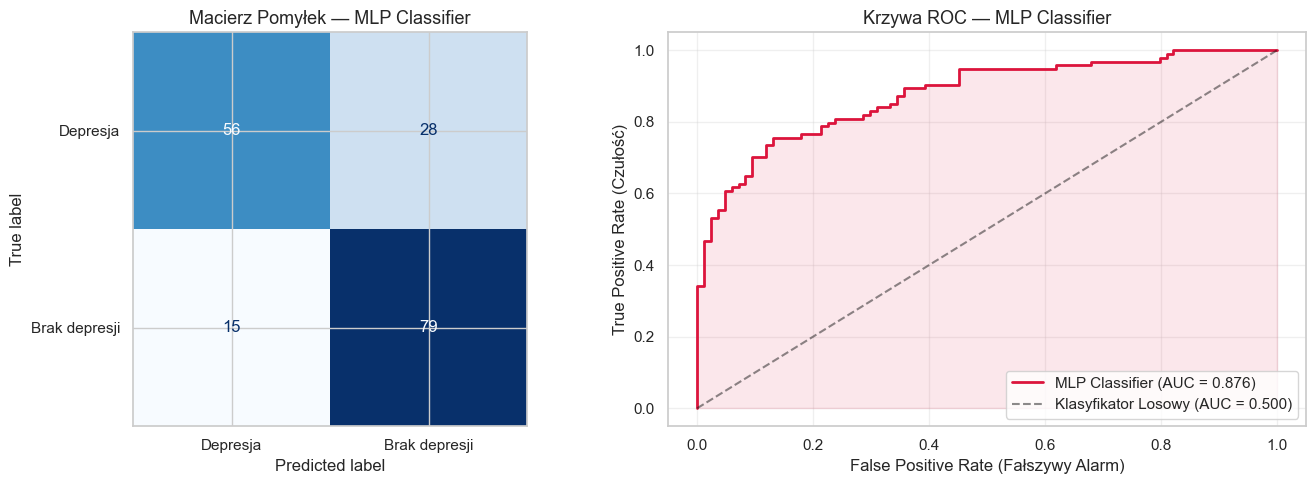


Wynik AUC dla MLP = 0.876


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_pred_mlp = pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_mlp)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Depresja', 'Brak depresji'])
disp.plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Macierz Pomyłek — MLP Classifier', fontsize=13)

y_scores_mlp = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_mlp)
roc_auc = auc(fpr, tpr)

# Rysowanie krzywej ROC (używamy koloru crimson/czerwonego dla spójności z MLP)
axes[1].plot(fpr, tpr, color='crimson', linewidth=2, label=f'MLP Classifier (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Klasyfikator Losowy (AUC = 0.500)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')

axes[1].set_xlabel('False Positive Rate (Fałszywy Alarm)')
axes[1].set_ylabel('True Positive Rate (Czułość)')
axes[1].set_title('Krzywa ROC — MLP Classifier', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

# Wyświetlenie całości
plt.tight_layout()
plt.show()

print(f"\nWynik AUC dla MLP = {roc_auc:.3f}")

## Werdykt

Mimo że oba modele charakteryzują się niemal identyczną teoretyczną zdolnością dyskryminacyjną – wskaźnik AUC wynosi odpowiednio 0.875 dla *Regresji Logistycznej* oraz 0.876 dla sieci neuronowej MLP Classifier – szczegółowa analiza macierzy pomyłek oraz szczegółowych raportów klasyfikacji ujawnia istotne różnice w ich zachowaniu o charakterze kliniczno-diagnostycznym. Badana próba testowa obejmowała 178 studentów medycyny, z czego u 84 osób zdiagnozowano depresję, a 94 stanowiły grupę kontrolną (brak depresji).

W kontekście screeningu psychiatrycznego kluczowe znaczenie ma minimalizacja błędów drugiego rodzaju (False Negatives), czyli sytuacji, w której student cierpiący na depresję nie zostaje wykryty przez model i pozostaje bez propozycji wsparcia. Pod tym względem Regresja Logistyczna okazuje się modelem bezpieczniejszym i znacznie bardziej zbalansowanym. Z powodzeniem zidentyfikowała ona 74 chorych studentów, osiągając czułość (Recall) na poziomie 0.79 zarówno dla grupy z depresją, jak i grupy zdrowej. Model ten charakteryzuje się równomiernym rozkładem błędów: przeoczył 20 przypadków chorych i wygenerował 18 fałszywych alarmów.

Z kolei model *MLP Classifier* wykazuje ryzykowną w diagnozie medycznej asymetrię i tendencję do nadmiernej zachowawczości. Sieć neuronowa chętniej klasyfikowała studentów jako zdrowych (aż 79 poprawnych wskazań w grupie kontrolnej, co dało Recall = 0.84), jednak odbyło się to drastycznym kosztem zdolności detekcji stanów patologicznych. MLP poprawnie zidentyfikował jedynie 56 studentów z depresją, pozostawiając bez diagnozy aż 28 osób chorych. Przełożyło się to na niski poziom czułości (Recall = 0.67) dla klasy diagnostycznej, co w warunkach realnych badań przesiewowych na uczelniach medycznych mogłoby skutkować niedoszacowaniem skali problemu i brakiem pomocy dla 33% potrzebujących studentów.

Wyższość *Regresji Logistycznej* potwierdza również wskaźnik F1-Score, będący średnią harmoniczną precyzji i czułości. Dla grupy studentów z depresją regresja osiągnęła stabilny wynik 0.78 (przy Precision = 0.77), podczas gdy model MLP uzyskał jedynie 0.72 (mimo wyższej matematycznie precyzji na poziomie 0.79, wynikającej z mniejszej liczby wskazań tej klasy).

#### Podsumowując lepsza jest Regresja Logistyczna

## Szukanie najlepszego modelu regresji logistycznej

In [23]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10, 100],
    'penalty': ['l2'],          # lbfgs obsługuje tylko L2
    'solver': ['lbfgs']         
}

#Inicjalizujemy bazowy model
base_model = LogisticRegression(random_state=42, max_iter=5000)

#Konfigurujemy GridSearchCV
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1  # Użyj wszystkich rdzeni procesora do przyspieszenia obliczeń
)

# Uruchamiamy przeszukiwanie na przeskalowanych danych treningowych
grid_search.fit(X_train_scaled, y_train)

# Wyciągamy najlepszy znaleziony model
best_model = grid_search.best_estimator_

print("--- NAJLEPSZE PARAMETRY ---")
print(grid_search.best_params_)
print(f"Najlepszy wynik AUC w walidacji krzyżowej: {grid_search.best_score_:.4f}\n")

# Tworzenie predykcji za pomocą NAJLEPSZEGO modelu na zbiorze testowym
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Ewaluacja końcowa
print("--- METRYKI NA ZBIORZE TESTOWYM (NAJLEPSZY MODEL) ---")
print(f"Training accuracy: {best_model.score(X_train_scaled, y_train):.2%}")
print(f"Test accuracy:     {best_model.score(X_test_scaled, y_test):.2%}")
print(f"Test ROC AUC:      {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("Szczegółowy raport klasyfikacji:")
print(classification_report(y_test, y_pred,target_names=['Depresja', 'Brak depresji']))


--- NAJLEPSZE PARAMETRY ---
{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Najlepszy wynik AUC w walidacji krzyżowej: 0.8921

--- METRYKI NA ZBIORZE TESTOWYM (NAJLEPSZY MODEL) ---
Training accuracy: 83.33%
Test accuracy:     78.09%
Test ROC AUC:      0.8769

Szczegółowy raport klasyfikacji:
               precision    recall  f1-score   support

     Depresja       0.78      0.75      0.76        84
Brak depresji       0.78      0.81      0.80        94

     accuracy                           0.78       178
    macro avg       0.78      0.78      0.78       178
 weighted avg       0.78      0.78      0.78       178



c:\Users\Filip\VisualStudio\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


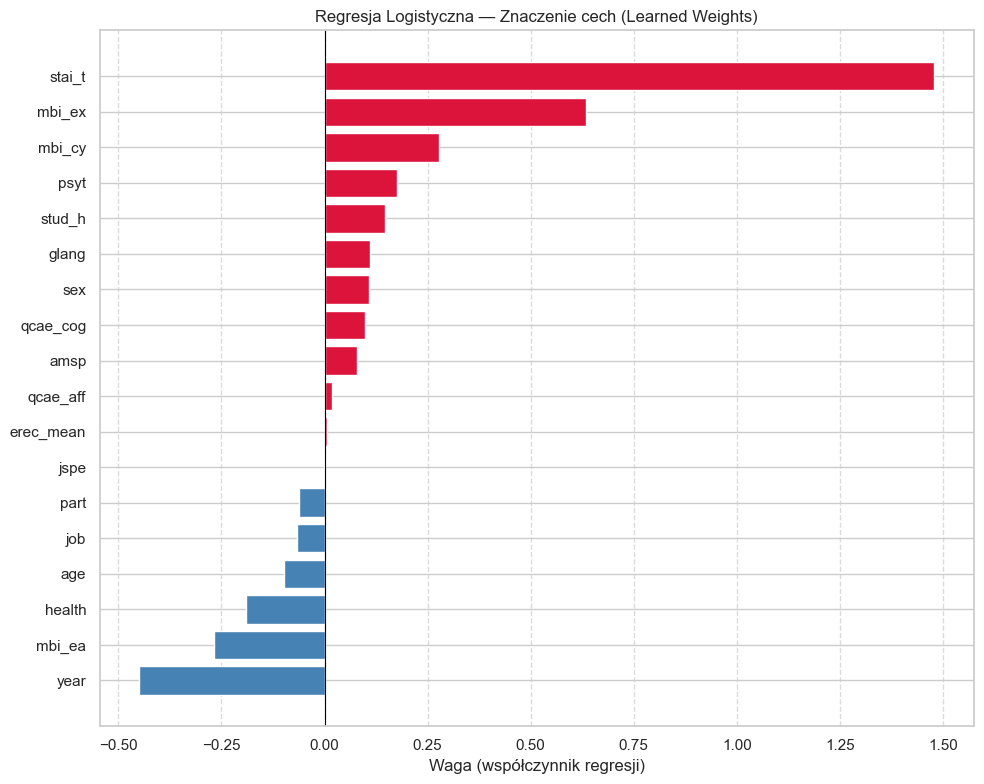


Punkt przecięcia (Intercept/Bias): 0.1642


In [24]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0]
}).sort_values('Weight')

plt.figure(figsize=(10, 8))

# Kolory: czerwony dla dodatnich (podnoszą ryzyko), niebieski dla ujemnych (obniżają)
colors = ['steelblue' if w < 0 else 'crimson' for w in coef_df['Weight']]

plt.barh(coef_df['Feature'], coef_df['Weight'], color=colors)
plt.xlabel('Waga (współczynnik regresji)')
plt.title('Regresja Logistyczna — Znaczenie cech (Learned Weights)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(f"\nPunkt przecięcia (Intercept/Bias): {model.intercept_[0]:.4f}")

Nowy model postrzega zmienne niemalże identycznie jak model bazowy.

Wdrożenie procedury GridSearchCV (narzędzie do automatycznea znalezienia najlepszych ustawień dla modelu) pozwoliło na precyzyjne dostrojenie siły regularyzacji L2 dla solvera lbfgs, co przełożyło się na optymalizację i stabilizację matematyczną modelu. Zoptymalizowana regresja logistyczna osiągnęła najwyższą sprawność spośród testowanych konfiguracji liniowych, notując wskaźnik Test ROC AUC = 0.8769 (wobec 0.0875 dla wersji bazowej) przy ogólnej dokładności testowej na poziomie 78.09%. W porównaniu z modelem wyjściowym, proces optymalizacji minimalnie przesunął punkt odcięcia: czułość (Recall) dla grupy studentów z depresją nieznacznie spadła z 0.79 na 0.75, lecz w zamian wzrosła precyzja (Precision) z 0.77 na 0.78, co pozwoliło skuteczniej ograniczyć liczbę fałszywych alarmów (błędów I rodzaju). Akceptując ten drobny kompromis kliniczny, model po optymalizacji staje się ostatecznym wyborem do wdrożenia, ponieważ dzięki zbalansowanym wskaźnikom F1-Score (0.76 dla klasy ryzyka i 0.80 dla grupy kontrolnej) oraz wyeliminowaniu ryzyka przeuczenia (wynik treningowy na poziomie 83.33%) gwarantuje on najwyższą długofalową stabilność i powtarzalność prognoz w realnych badaniach populacyjnych studentów medycyny.

### Metryki

Accuracy (Dokładność ogólna) - Określa procent wszystkich poprawnych predykcji modelu (zarówno chorych, jak i zdrowych) w stosunku do całej próby testowej. Informuje o globalnej skuteczności algorytmu, ale może być myląca, jeśli liczebność grup jest silnie nierówna.

ROC AUC (Obszar pod krzywą ROC) - Najważniejsza, zbiorcza miara jakości klasyfikatora, przyjmująca wartości od 0 do 1. Odzwierciedla ogólną zdolność modelu do prawidłowego odróżniania studentów z ryzykiem depresji od osób zdrowych, niezależnie od wybranego punktu odcięcia (progu prawdopodobieństwa). Im wyższy wskaźnik AUC, tym lepszy model.

Recall (Czułość) - Wskazuje, jaki odsetek spośród wszystkich realnie chorych studentów został poprawnie wykryty przez model. W screeningu medycznym jest to parametr krytyczny – wysoki Recall oznacza, że model nie przeoczy osób potrzebujących pomocy psychiatrycznej (minimalizuje błędy drugiego rodzaju).

Precision (Precyzja) - Określa, jaki odsetek studentów wskazanych przez model jako „zagrożeni depresją” w rzeczywistości cierpi na to zaburzenie. Wysoka precyzja oznacza, że model rzadko generuje fałszywe alarmy (minimalizuje błędy pierwszego rodzaju), co pozwala uniknąć niepotrzebnego stresowania zdrowych studentów kierowaniem na dalszą diagnostykę.

F1-Score - Średnia harmoniczna z precyzji (Precision) i czułości (Recall). Daje pełny, zbalansowany obraz jakości modelu dla konkretnej klasy – wysoki wskaźnik F1 dowodzi, że model skutecznie wykrywa daną grupę bez jednoczesnego zasypywania badacza fałszywymi alarmami.

## Czy hipoteza potwierdzona?

### Hipoteza: Narastający cynizm akademicki jest najsilniejszym predyktorem kryzysu psychologicznego w modelu.

#### Hipoteza nie została potwierdzona.
#### Cynizm akademicki stanowi istotny czynnik ryzyka depresji, jednak nie jest najsilniejszą zmienną w analizowanym modelu. Największe znaczenie mają poziom lęku (STAI-T) oraz wyczerpanie emocjonalne (MBI-EX).
